# Módulo 4 — Preparação dos Dados com Python

##Aluno: Alexandre Barbosa e Julio Cesar dos Santos

###Objetivos da atividade:

#### Compreensão dos Dados
Revisitar e validar o entendimento inicial da base PRF.

#### Preparação dos Dados
Preparar a base de dados para EDA, dashboard e árvore de decisão.

### Importar bibliotecas

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

from datetime import datetime
import unicodedata

pd.set_option("display.max_columns", 120)

pd.set_option("display.width", 160)

### Montar Google Drive
Observação: O roteiro sugere a criação de pastas para melhor organização, mas, como no Google Colab as pastas são temporárias, decidimos por criar pastas no Drive para garantir que as pastas e dados sejam persistentes entre as sessões, sem o risco de perder nenhum dado.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Definição de Parâmetros do Projeto
Aqui, definimos os caminhos dos arquivos e as configurações de codificação e separadores, garantindo que os caminhos dos arquivos estejam corretos em relação à sua estrutura de pastas no Google Drive.

In [3]:
# Definindo a pasta raiz do seu projeto no Google Drive
RAIZ = Path("/content/drive/MyDrive/Aponti - Análise de Dados/Projeto Módulo 4")

PASTAS = [
    "dados_brutos",
    "dados_tratados",
    "notebooks",
    "sql",
    "dashboards",
    "relatorios",
    "apresentacao",
    "logs"
]

for pasta in PASTAS:
    (RAIZ / pasta).mkdir(parents=True, exist_ok=True)

print("Pastas verificadas/criadas:")
for pasta in PASTAS:
    print("-", RAIZ / pasta)

Pastas verificadas/criadas:
- /content/drive/MyDrive/Aponti - Análise de Dados/Projeto Módulo 4/dados_brutos
- /content/drive/MyDrive/Aponti - Análise de Dados/Projeto Módulo 4/dados_tratados
- /content/drive/MyDrive/Aponti - Análise de Dados/Projeto Módulo 4/notebooks
- /content/drive/MyDrive/Aponti - Análise de Dados/Projeto Módulo 4/sql
- /content/drive/MyDrive/Aponti - Análise de Dados/Projeto Módulo 4/dashboards
- /content/drive/MyDrive/Aponti - Análise de Dados/Projeto Módulo 4/relatorios
- /content/drive/MyDrive/Aponti - Análise de Dados/Projeto Módulo 4/apresentacao
- /content/drive/MyDrive/Aponti - Análise de Dados/Projeto Módulo 4/logs


### Definir Parâmetros do Projeto

### Definição de Parâmetros do Projeto
Aqui, definimos os caminhos dos arquivos e as configurações de codificação e separadores, garantindo que os caminhos dos arquivos estejam corretos em relação à sua estrutura de pastas no Google Drive.

In [4]:
# Definição dos caminhos dos arquivos, combinando com a RAIZ do projeto no Google Drive
ARQUIVO_BRUTO = RAIZ / "dados_brutos/acidentes2025.csv"
ARQUIVO_BASE_ANALITICA = RAIZ / "dados_tratados/base_analitica_prf_2025.csv"
ARQUIVO_BASE_MODELAVEL = RAIZ / "dados_tratados/base_modelavel_prf_2025.csv"
ARQUIVO_DICIONARIO = RAIZ / "dados_tratados/dicionario_variaveis_modulo4.csv"
ARQUIVO_DECISOES = RAIZ / "logs/decisoes_tratamento_modulo4.md"
ARQUIVO_README = RAIZ / "README.md"

# Definição de separadores e encodings
SEPARADOR = ";"
ENCODING_ENTRADA = "latin1"
ENCODING_SAIDA = "utf-8-sig"

### Leitura do Arquivo CSV Bruto
Foi criada uma função para ler o arquivo CSV, tentando diferentes encodings, e então usá-la para carregar os dados brutos na memória.

In [5]:
def ler_csv_prf(caminho, sep=";", encodings=("latin1","utf-8","utf-8-sig")):
    ultimo_erro = None
    for enc in encodings:
        try:
            print(f"Tentando encoding={{enc}}...")
            return pd.read_csv(
                caminho, sep=sep,
                encoding=enc, low_memory=False)
        except Exception as erro:
            ultimo_erro = erro
            print(f"Falhou com {{enc}}: {{erro}}")
    raise ultimo_erro

# Lendo o arquivo CSV bruto usando a função definida
df = ler_csv_prf(ARQUIVO_BRUTO, sep=SEPARADOR)

# Exibindo as primeiras linhas do DataFrame para verificar o carregamento
display(df.head())

Tentando encoding={enc}...


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


### Padronizar nomes das colunas

In [6]:
def normalizar_nome_coluna(nome):
    nome = str(nome).strip().lower()
    nome = unicodedata.normalize("NFKD", nome).encode("ascii", "ignore").decode("utf-8")
    nome = nome.replace(" ", "_").replace("-", "_").replace("/", "_")
    while "__" in nome:
        nome = nome.replace("__", "_")
    return nome.strip("_")

df.columns = [normalizar_nome_coluna(c) for c in df.columns]
renomear = { "condicao_meteorologica": "condicao_metereologica"}
df = df.rename(columns={
    k:v for k,v in renomear.items() if k in df.columns})

print(df.columns.tolist())

['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']


### Conferir Colunas Esperadas

In [7]:
colunas_esperadas = ["data_inversa", "dia_semana", "horario", "uf", "br", "municipio", "causa_acidente", "tipo_acidente", "classificacao_acidente", "fase_dia", "condicao_metereologica", "tipo_pista", "tracado_via", "uso_solo", "pessoas", "mortos", "feridos_leves", "feridos_graves", "feridos", "veiculos"]
faltantes = [c for c in colunas_esperadas if c not in df.columns]
print("Colunas faltantes:", faltantes)
if faltantes:
    print("Atenção: ajuste nomes ou confirme o dicionário oficial da PRF usado no arquivo.")

Colunas faltantes: []


### Retrato Inicial da Base

In [8]:
print("Dimensões:", df.shape)
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])
display(df.head())
display(df.sample(5, random_state=42))

Dimensões: (72529, 30)
Linhas: 72529
Colunas: 30


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
6366,691804,2025-03-15,sábado,12:30:00,ES,101,67,SAO MATEUS,Condutor desrespeitou a iluminação vermelha do...,Colisão transversal,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Simples,Rotatória,Sim,4,0,0,2,1,2,2,4,"-18,72802869","-39,85997558",SPRF-ES,DEL04-ES,UOP02-DEL04-ES
9405,704622,2025-07-13,domingo,22:30:00,PE,423,"74,1",JUPI,Condutor deixou de manter distância do veículo...,Colisão traseira,Sem Vítimas,Plena Noite,Decrescente,Céu Claro,Simples,Aclive;Reta,Sim,2,0,0,0,2,0,0,2,"-8,7160879","-36,4219923",SPRF-PE,DEL03-PE,UOP01-DEL03-PE
26102,663260,2025-02-23,domingo,18:10:00,BA,242,231,ITABERABA,Animais na Pista,Atropelamento de Animal,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Sim,1,0,1,0,0,0,1,1,"-12,511706","-40,324247",SPRF-BA,DEL06-BA,UOP02-DEL06-BA
28616,667036,2025-03-13,quinta-feira,19:55:00,DF,20,"9,9",BRASILIA,Reação tardia ou ineficiente do condutor,Engavetamento,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Dupla,Reta,Não,6,0,4,0,2,0,4,3,"-15,6502715","-47,7763723",SPRF-DF,DEL02-DF,UOP01-DEL02-DF
1696,660353,2025-02-09,domingo,19:05:00,MA,222,665,ACAILANDIA,Pedestre andava na pista,Atropelamento de Pedestre,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Declive,Não,3,0,1,1,0,1,2,3,"-4,89367779","-47,38426513",SPRF-MA,DEL04-MA,UOP03-DEL04-MA


### Tipos de Dados e Memória

In [9]:
df.info(memory_usage="deep")

resumo_tipos = (
df.dtypes.astype(str)
.value_counts()
.rename_axis("tipo")
.reset_index(name="qtd_colunas")

)

display(resumo_tipos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      72529 non-null  int64 
 1   data_inversa            72529 non-null  object
 2   dia_semana              72529 non-null  object
 3   horario                 72529 non-null  object
 4   uf                      72529 non-null  object
 5   br                      72529 non-null  int64 
 6   km                      72529 non-null  object
 7   municipio               72529 non-null  object
 8   causa_acidente          72529 non-null  object
 9   tipo_acidente           72529 non-null  object
 10  classificacao_acidente  72528 non-null  object
 11  fase_dia                72529 non-null  object
 12  sentido_via             72529 non-null  object
 13  condicao_metereologica  72529 non-null  object
 14  tipo_pista              72529 non-null  object
 15  tr

,tipo,qtd_colunas
0,object,20
1,int64,10


### Diagnóstico de Valores Ausentes

In [10]:
nulos = pd.DataFrame({ "qtd_nulos": df.isna().sum(),
"perc_nulos": df.isna().mean() * 100
}).sort_values(
"perc_nulos", ascending=False)
display(nulos[nulos["qtd_nulos"] > 0])

,qtd_nulos,perc_nulos
uop,38,0.052393
delegacia,22,0.030333
regional,2,0.002758
classificacao_acidente,1,0.001379


### Diagnóstico e Remoção de Duplicidades

In [11]:
qtd_duplicadas = df.duplicated().sum()
print("Duplicidades exatas:", qtd_duplicadas)
if qtd_duplicadas > 0:
    df = df.drop_duplicates().copy()
    print("Duplicidades removidas.")
    print("Nova dimensão:", df.shape)

Duplicidades exatas: 0


### Cardinalidade das Categorias

In [12]:
categoricas = df.select_dtypes(include="object").columns
cardinalidade = (
df[categoricas]
.nunique(dropna=True)
.sort_values(ascending=False)
.reset_index()
)
cardinalidade.columns = ["variavel", "qtd_categorias"]
display(cardinalidade.head(30))

,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


### Converter Colunas Numéricas

Observação: Para a coluna 'km', tivemos que substituir vírgulas por pontos antes da conversão para numérico, pois, mais na frente, esses dados seriam identificados como nulos na etapa de padronização dos textos.

In [13]:
colunas_numericas = [ "br","km","pessoas","mortos","feridos", "feridos_leves","feridos_graves", "ilesos","ignorados","veiculos"]

for coluna in colunas_numericas:
  if coluna in df.columns:
    if coluna == 'km':

      df[coluna] = df[coluna].astype(str).str.replace(',', '.', regex=False)
    df[coluna] = pd.to_numeric( df[coluna], errors="coerce")

print(df[[c for c in colunas_numericas if c in df.columns]].dtypes)

br                  int64
km                float64
pessoas             int64
mortos              int64
feridos             int64
feridos_leves       int64
feridos_graves      int64
ilesos              int64
ignorados           int64
veiculos            int64
dtype: object


### Tratar Datas e Criar Variáveis Temporais

In [14]:
df["data_inversa"] = pd.to_datetime(df["data_inversa"], errors="coerce")
df["ano"] = df["data_inversa"].dt.year
df["mes"] = df["data_inversa"].dt.month
df["trimestre"] = df["data_inversa"].dt.quarter
df["dia_semana_num"] = df["data_inversa"].dt.dayofweek
df["fim_de_semana"] = df["dia_semana_num"].isin([5, 6]).astype(int)

In [15]:
#Verificando se as novas variáveis foram criadas corretamente

print('Verificando as novas variáveis temporais:')
display(df[['data_inversa', 'ano', 'mes', 'trimestre', 'dia_semana_num', 'fim_de_semana']].sample(5, random_state=42))
print('\nTipos de dados das novas variáveis:')
display(df[['data_inversa', 'ano', 'mes', 'trimestre', 'dia_semana_num', 'fim_de_semana']].dtypes)

Verificando as novas variáveis temporais:


,data_inversa,ano,mes,trimestre,dia_semana_num,fim_de_semana
6366,2025-03-15,2025,3,1,5,1
9405,2025-07-13,2025,7,3,6,1
26102,2025-02-23,2025,2,1,6,1
28616,2025-03-13,2025,3,1,3,0
1696,2025-02-09,2025,2,1,6,1



Tipos de dados das novas variáveis:


,0
data_inversa,datetime64[ns]
ano,int32
mes,int32
trimestre,int32
dia_semana_num,int32
fim_de_semana,int64


### Tratar Horário e Criar Turno

In [16]:
horario_limpo = df["horario"].astype(str).str.strip()
df["hora"] = pd.to_datetime(horario_limpo, format="%H:%M:%S", errors="coerce").dt.hour

def classificar_turno(hora):
    if pd.isna(hora):
        return "IGNORADO"
    if 0 <= hora <= 5:
        return "MADRUGADA"
    if 6 <= hora <= 11:
        return "MANHA"
    if 12 <= hora <= 17:
        return "TARDE"
    return "NOITE"

df["turno"] = df["hora"].apply(classificar_turno)

# Verificando as novas colunas que nós criamos
print("Verificando as novas colunas 'hora' e 'turno':")
display(df[['horario', 'hora', 'turno']].sample(5, random_state=42))
print('\nTipos de dados das novas colunas:')
display(df[['hora', 'turno']].dtypes)
print('\nContagem de valores únicos para a coluna "turno":')
display(df['turno'].value_counts())

Verificando as novas colunas 'hora' e 'turno':


,horario,hora,turno
6366,12:30:00,12,TARDE
9405,22:30:00,22,NOITE
26102,18:10:00,18,NOITE
28616,19:55:00,19,NOITE
1696,19:05:00,19,NOITE



Tipos de dados das novas colunas:


,0
hora,int32
turno,object



Contagem de valores únicos para a coluna "turno":


,count
turno,
TARDE,22302
MANHA,20859
NOITE,20461
MADRUGADA,8907


### Criar Faixa Horária

In [17]:
def criar_faixa_horaria(hora):
    if pd.isna(hora):
        return "IGNORADO"
    inicio = int(hora // 3) * 3
    fim = inicio + 2
    return f"{inicio:02d}h-{fim:02d}h"

df["faixa_horaria"] = df["hora"].apply(
    criar_faixa_horaria)

display( df["faixa_horaria"].value_counts(dropna=False).sort_index())

,count
faixa_horaria,
00h-02h,3959
03h-05h,4948
06h-08h,11517
09h-11h,9342
12h-14h,9678
15h-17h,12624
18h-20h,13473
21h-23h,6988


In [18]:
colunas_texto = df.select_dtypes(include="object").columns
for coluna in colunas_texto:
  df[coluna] = (
  df[coluna]
  .astype("string")
  .str.strip()
  .str.upper()
  )
  df[coluna] = df[coluna].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA, "NULL": pd.NA})
print("Colunas textuais padronizadas:", len(colunas_texto))

# Exibindo um diagnóstico de nulos atualizado para verificar as mudanças
print("\nDiagnóstico atualizado de valores ausentes após a padronização:")
nulos_atualizado = pd.DataFrame({
    "qtd_nulos": df.isna().sum(),
    "perc_nulos": df.isna().mean() * 100
}).sort_values("perc_nulos", ascending=False)
display(nulos_atualizado[nulos_atualizado["qtd_nulos"] > 0])

Colunas textuais padronizadas: 20

Diagnóstico atualizado de valores ausentes após a padronização:


,qtd_nulos,perc_nulos
uop,38,0.052393
delegacia,22,0.030333
regional,2,0.002758
classificacao_acidente,1,0.001379


### Tratar nulos categóricos

In [19]:
categoricas_importantes = ["uf", "municipio", "causa_acidente", "tipo_acidente", "fase_dia", "condicao_metereologica", "tipo_pista", "tracado_via", "uso_solo", "classificacao_acidente", "dia_semana"]

for coluna in categoricas_importantes:
    if coluna in df.columns:
            df[coluna] = df[coluna].fillna('IGNORADO')

print("\nVerificação de nulos nas colunas categóricas importantes após o tratamento:")
display(df[categoricas_importantes].isna().sum().sort_values(ascending=False))


Verificação de nulos nas colunas categóricas importantes após o tratamento:


,0
uf,0
municipio,0
causa_acidente,0
tipo_acidente,0
fase_dia,0
condicao_metereologica,0
tipo_pista,0
tracado_via,0
uso_solo,0
classificacao_acidente,0


### Decisão de Tratamento de Nulos para Variáveis Categóricas

**Estratégia Adotada:**
Para as variáveis categóricas que apresentaram valores ausentes (`NaN` ou `pd.NA`), a decisão foi preencher esses nulos com a string **'IGNORADO'**.

**Justificativa:**
*   **Preservação da Informação:** Evita a remoção de linhas inteiras que poderiam conter informações valiosas em outras colunas, mesmo com a ausência em uma variável categórica específica.
*   **Identificação Explícita:** A categoria 'IGNORADO' torna explícita a condição de dado ausente, o que pode ser útil em análises futuras, permitindo que se investigue se a ausência de informação tem algum padrão ou impacto nos resultados.

### Tratar Nulos Numéricos de Contagem

Observação: os valores nulos das colunas de contagem ("mortos","feridos","feridos_leves", "feridos_graves","pessoas" e "veiculos") foram substituídos por zero, adotando-se a hipótese operacional de que a ausência do valor representa inexistência da ocorrência registrada para aquela categoria de vítima.

In [20]:
contagem_vitimas = ["mortos","feridos","feridos_leves", "feridos_graves","pessoas","veiculos"]

for coluna in contagem_vitimas:
    if coluna in df.columns:
        df[coluna] = df[coluna].fillna(0)
        print(f"Nulos na coluna '{coluna}' preenchidos com 0.")

print("\nVerificação de nulos nas colunas de contagem após o tratamento:")
display(df[contagem_vitimas].isna().sum().sort_values(ascending=False))

Nulos na coluna 'mortos' preenchidos com 0.
Nulos na coluna 'feridos' preenchidos com 0.
Nulos na coluna 'feridos_leves' preenchidos com 0.
Nulos na coluna 'feridos_graves' preenchidos com 0.
Nulos na coluna 'pessoas' preenchidos com 0.
Nulos na coluna 'veiculos' preenchidos com 0.

Verificação de nulos nas colunas de contagem após o tratamento:


,0
mortos,0
feridos,0
feridos_leves,0
feridos_graves,0
pessoas,0
veiculos,0


### Criar Variável-Alvo: acidente_fatal

Regra

1 quando mortos >= 1

0 quando mortos = 0

In [21]:
df["acidente_fatal"] = (df["mortos"] >= 1).astype(int)

#Validação

validacao_alvo = (
    df["acidente_fatal"].value_counts(dropna=False).rename_axis("acidente_fatal").reset_index(name="qtd")
)
validacao_alvo["perc"] = ( validacao_alvo["qtd"] / validacao_alvo["qtd"].sum() * 100)
display(validacao_alvo)

,acidente_fatal,qtd,perc
0,0,67319,92.816666
1,1,5210,7.183334


### Validar Logicamente o Alvo

In [22]:
violacoes = df.loc[
    ((df["mortos"] >= 1) & (df["acidente_fatal"] != 1)) |
    ((df["mortos"] == 0) & (df["acidente_fatal"] != 0))
]

print(f"Violações da regra do alvo: {len(violacoes)}")

if len(violacoes) > 0:
    display(violacoes)

assert len(violacoes) == 0, \
    "Há erro na criação de acidente_fatal."

Violações da regra do alvo: 0


### Criar Indicadores de Gravidade

acidente_grave:

1 se mortos >= 1 ou feridos_graves >= 1

total_vitimas:

mortos + feridos_leves + feridos_graves

indice_gravidade:

mortos×3 + feridos_graves×2 + feridos_leves

In [23]:
df["acidente_grave"] = np.where(
    (df["mortos"] >= 1) | (df["feridos_graves"] >= 1),
    1,
    0
)

df["total_vitimas"] = (
    df["mortos"] + df["feridos_leves"] + df["feridos_graves"]
)

df["indice_gravidade"] = (
    df["mortos"] * 3 + df["feridos_graves"] * 2 + df["feridos_leves"]
)

display(df[["mortos", "feridos_leves", "feridos_graves", "total_vitimas",
"indice_gravidade", "acidente_grave"]].head())

,mortos,feridos_leves,feridos_graves,total_vitimas,indice_gravidade,acidente_grave
0,0,1,0,1,1,0
1,1,1,0,2,4,1
2,0,3,0,3,3,0
3,0,1,0,1,1,0
4,0,1,1,2,3,1


### Criar BR Formatada e Chave de Localidade


In [24]:
def formatar_br(valor):
  if pd.isna(valor) or valor == 0:
    return "BR-IGNORADA"
  return f"BR-{int(valor):03d}"

df["br_formatada"] = df["br"].apply(formatar_br)

df["chave_localidade"] =  (
    df["uf"].astype(str)
    + "_"
    + df["municipio"].astype(str)
    + "_"
    + df["br_formatada"].astype(str)
)

display(df[["br", "br_formatada", "uf", "municipio", "chave_localidade"]].head())

,br,br_formatada,uf,municipio,chave_localidade
0,116,BR-116,SP,GUARULHOS,SP_GUARULHOS_BR-116
1,116,BR-116,CE,PENAFORTE,CE_PENAFORTE_BR-116
2,369,BR-369,PR,CORNELIO PROCOPIO,PR_CORNELIO PROCOPIO_BR-369
3,116,BR-116,PR,CAMPINA GRANDE DO SUL,PR_CAMPINA GRANDE DO SUL_BR-116
4,251,BR-251,MG,FRANCISCO SA,MG_FRANCISCO SA_BR-251


### Checagens Rápidas Após Transformação

Para evitar erros até esse ponto do projeto. Aqui, além do que foi sugerido pela apostila, pensei em criar uma função para fazer essas checagens sempre que precisasse.

Observação: na apostila, ele não pede "Totais de mortos e feridos", mas no pdf do professor esse item está incluído. Para trazer a informação completa, optei por incluir esse item também.


In [25]:
def fazer_checagens(df):
    return {
        "linhas": len(df),
        "colunas": df.shape[1],
        "acidentes_fatais": int(df["acidente_fatal"].sum()),
        "taxa_fatalidade": float(df["acidente_fatal"].mean()),
        "total_mortos": int(df["mortos"].sum()),
        "total_feridos": int(df["feridos"].sum()) if "feridos" in df.columns else None,
}

checagens = fazer_checagens(df)
checagens


{'linhas': 72529,
 'colunas': 44,
 'acidentes_fatais': 5210,
 'taxa_fatalidade': 0.07183333563126473,
 'total_mortos': 6043,
 'total_feridos': 83550}

### Ranking Rápido de Categorias

Observação: como adicional, criei uma coluna ranking com uma numeração adequada (começando do 1), em substituição à coluna original, que começava do 0 e poderia confundir na visualização.



In [26]:
def ranking_categoria(base, coluna, n=10):
    resultado = (
      base[coluna].value_counts(dropna=False).head(n).rename_axis(coluna).reset_index(name="qtd")

  )

    resultado.insert(0, "ranking", range(1, len(resultado) + 1))

    return resultado

display(ranking_categoria(df, "tipo_acidente", 10)
.style.hide(axis="index"))
display(ranking_categoria(df, "causa_acidente", 10)
.style.hide(axis="index"))

ranking,tipo_acidente,qtd
1,COLISÃO TRASEIRA,14360
2,SAÍDA DE LEITO CARROÇÁVEL,10209
3,COLISÃO TRANSVERSAL,9306
4,COLISÃO LATERAL MESMO SENTIDO,7885
5,TOMBAMENTO,6351
6,COLISÃO COM OBJETO,5109
7,COLISÃO FRONTAL,4739
8,QUEDA DE OCUPANTE DE VEÍCULO,3450
9,ATROPELAMENTO DE PEDESTRE,3057
10,COLISÃO LATERAL SENTIDO OPOSTO,2152


ranking,causa_acidente,qtd
1,AUSÊNCIA DE REAÇÃO DO CONDUTOR,11469
2,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,10799
3,ACESSAR A VIA SEM OBSERVAR A PRESENÇA DOS OUTROS VEÍCULOS,7097
4,CONDUTOR DEIXOU DE MANTER DISTÂNCIA DO VEÍCULO DA FRENTE,4413
5,VELOCIDADE INCOMPATÍVEL,4088
6,MANOBRA DE MUDANÇA DE FAIXA,4016
7,INGESTÃO DE ÁLCOOL PELO CONDUTOR,3685
8,DEMAIS FALHAS MECÂNICAS OU ELÉTRICAS,3385
9,TRANSITAR NA CONTRAMÃO,2475
10,CONDUTOR DORMINDO,2116


### Taxa Fatal por Categoria

In [27]:
def taxa_fatal_categoria(base, coluna, minimo=30):
  resultado = (
      base.groupby(coluna, dropna=False)
      .agg(
          qtd_acidentes = ("acidente_fatal", "size"),
          acidentes_fatais = ("acidente_fatal", "sum"),
          taxa_fatalidade = ("acidente_fatal", "mean")
      )
      .reset_index()
  )
  resultado = resultado[resultado["qtd_acidentes"] >= minimo]
  return resultado.sort_values("taxa_fatalidade", ascending=False)

display(taxa_fatal_categoria(df, "tipo_acidente", 30)
.head(10)
.style.hide(axis="index")
)

tipo_acidente,qtd_acidentes,acidentes_fatais,taxa_fatalidade
ATROPELAMENTO DE PEDESTRE,3057,902,0.295061
COLISÃO FRONTAL,4739,1396,0.294577
COLISÃO LATERAL SENTIDO OPOSTO,2152,212,0.098513
EVENTOS ATÍPICOS,287,23,0.080139
ATROPELAMENTO DE ANIMAL,1133,68,0.060018
SAÍDA DE LEITO CARROÇÁVEL,10209,605,0.059261
COLISÃO COM OBJETO,5109,297,0.058133
CAPOTAMENTO,1373,63,0.045885
COLISÃO TRANSVERSAL,9306,427,0.045884
COLISÃO TRASEIRA,14360,619,0.043106


###Gráfico Simples de Conferência


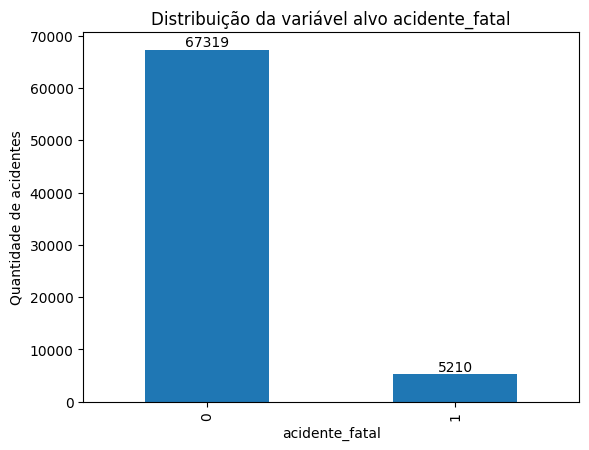

In [28]:
ax = df["acidente_fatal"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Distribuição da variável alvo acidente_fatal")
ax.set_xlabel("acidente_fatal")
ax.set_ylabel("Quantidade de acidentes")
ax.bar_label(ax.containers[0])
plt.show()


###Gerar Base Analítica Completa

In [29]:
base_analitica = df.copy()
display(base_analitica.head())

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano,mes,trimestre,dia_semana_num,fim_de_semana,hora,turno,faixa_horaria,acidente_fatal,acidente_grave,total_vitimas,indice_gravidade,br_formatada,chave_localidade
0,652493,2025-01-01,QUARTA-FEIRA,06:20:00,SP,116,225.0,GUARULHOS,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,TOMBAMENTO,COM VÍTIMAS FERIDAS,PLENO DIA,DECRESCENTE,CÉU CLARO,MÚLTIPLA,RETA;DECLIVE,SIM,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP,2025,1,1,2,0,6,MANHA,06H-08H,0,0,1,1,BR-116,SP_GUARULHOS_BR-116
1,652519,2025-01-01,QUARTA-FEIRA,07:50:00,CE,116,546.2,PENAFORTE,PISTA ESBURACADA,COLISÃO FRONTAL,IGNORADO,PLENO DIA,CRESCENTE,CÉU CLARO,SIMPLES,RETA,NÃO,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE,2025,1,1,2,0,7,MANHA,06H-08H,1,1,2,4,BR-116,CE_PENAFORTE_BR-116
2,652522,2025-01-01,QUARTA-FEIRA,08:45:00,PR,369,88.2,CORNELIO PROCOPIO,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,COLISÃO TRASEIRA,COM VÍTIMAS FERIDAS,PLENO DIA,CRESCENTE,SOL,DUPLA,RETA;ACLIVE,SIM,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR,2025,1,1,2,0,8,MANHA,06H-08H,0,0,3,3,BR-369,PR_CORNELIO PROCOPIO_BR-369
3,652544,2025-01-01,QUARTA-FEIRA,11:00:00,PR,116,74.0,CAMPINA GRANDE DO SUL,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,SAÍDA DE LEITO CARROÇÁVEL,COM VÍTIMAS FERIDAS,PLENO DIA,CRESCENTE,CÉU CLARO,DUPLA,RETA,NÃO,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR,2025,1,1,2,0,11,MANHA,09H-11H,0,0,1,1,BR-116,PR_CAMPINA GRANDE DO SUL_BR-116
4,652549,2025-01-01,QUARTA-FEIRA,09:30:00,MG,251,471.0,FRANCISCO SA,VELOCIDADE INCOMPATÍVEL,COLISÃO FRONTAL,COM VÍTIMAS FERIDAS,PLENO DIA,DECRESCENTE,CHUVA,SIMPLES,CURVA;DECLIVE,NÃO,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG,2025,1,1,2,0,9,MANHA,09H-11H,0,1,2,3,BR-251,MG_FRANCISCO SA_BR-251


In [30]:
print("Base analítica:", base_analitica.shape)
print("Colunas:", base_analitica.columns.tolist())

Base analítica: (72529, 44)
Colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'ano', 'mes', 'trimestre', 'dia_semana_num', 'fim_de_semana', 'hora', 'turno', 'faixa_horaria', 'acidente_fatal', 'acidente_grave', 'total_vitimas', 'indice_gravidade', 'br_formatada', 'chave_localidade']


###Selecionar Variáveis Modeláveis


In [31]:
variaveis_modelaveis = [
"uf", "br_formatada", "municipio", "mes", "trimestre",
"dia_semana", "dia_semana_num", "fim_de_semana",
"hora", "faixa_horaria", "turno", "fase_dia",
"causa_acidente", "tipo_acidente", "condicao_metereologica",
"tipo_pista", "tracado_via", "uso_solo",
"acidente_fatal"
]

variaveis_modelaveis = [c for c in variaveis_modelaveis if c in df.columns]

base_modelavel = df[variaveis_modelaveis].copy()

print("Base modelável:", base_modelavel.shape)

Base modelável: (72529, 19)


###Verificar data leakage

In [32]:
variaveis_proibidas = [
    "mortos",
    "feridos",
    "feridos_leves",
    "feridos_graves",
    "total_vitimas",
    "indice_gravidade",
    "acidente_grave",
    "classificacao_acidente"
]

def verificar_data_leakage(base, proibidas):
  presentes = [
      c for c in proibidas
      if c in base.columns
  ]

  if presentes:
    raise ValueError(
        f"Data leakage: {presentes}"
    )
  return "Ok, nenhuma variável proibida foi encontrada."

verificar_data_leakage(
    base_modelavel,
    variaveis_proibidas
)

'Ok, nenhuma variável proibida foi encontrada.'

###Tratamento Final de Nulos na Base Modelável


In [33]:
for coluna in base_modelavel.columns:
  if coluna == "acidente_fatal":
    continue

  if (
      base_modelavel[coluna].dtype =="object"
      or str(base_modelavel[coluna].dtype) == "string"

  ):
      base_modelavel[coluna] = (
          base_modelavel[coluna].fillna("IGNORADO")
    )
  else:

    base_modelavel[coluna] = (
        base_modelavel[coluna].fillna(-1)
    )

print(
    base_modelavel.isna().sum()
    .sort_values(ascending=False)
    .head()
  )


uf              0
br_formatada    0
municipio       0
mes             0
trimestre       0
dtype: int64


### Exportar Bases Tratadas


In [34]:
base_analitica.to_csv(
    ARQUIVO_BASE_ANALITICA,
    index=False,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

base_modelavel.to_csv(
    ARQUIVO_BASE_MODELAVEL,
    index=False,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

print("Bases exportadas com sucesso:")
print(ARQUIVO_BASE_ANALITICA)
print(ARQUIVO_BASE_MODELAVEL)

Bases exportadas com sucesso:
/content/drive/MyDrive/Aponti - Análise de Dados/Projeto Módulo 4/dados_tratados/base_analitica_prf_2025.csv
/content/drive/MyDrive/Aponti - Análise de Dados/Projeto Módulo 4/dados_tratados/base_modelavel_prf_2025.csv


###Reabrir arquivos exportados

In [35]:
valid_analitica = pd.read_csv(ARQUIVO_BASE_ANALITICA, sep=SEPARADOR, encoding=ENCODING_SAIDA)
valid_modelavel = pd.read_csv(ARQUIVO_BASE_MODELAVEL, sep=SEPARADOR, encoding=ENCODING_SAIDA)

print("Analítica reaberta:", valid_analitica.shape)
print("Modelável reaberta:", valid_modelavel.shape)

assert len(valid_analitica) == len(base_analitica)
assert len(valid_modelavel) == len(base_modelavel)

Analítica reaberta: (72529, 44)
Modelável reaberta: (72529, 19)


###Gerar dicionário das variáveis criadas

In [36]:
linhas_dic = [
{"variavel": "acidente_fatal", "descricao": "1 se mortos >= 1; 0 se mortos = 0", "uso":
"alvo"},
{"variavel": "total_vitimas", "descricao": "mortos + feridos leves + feridos graves", "uso":
"analise/dashboard"},
{"variavel": "indice_gravidade", "descricao": "mortos*3 + feridos_graves*2 + feridos_leves",
"uso": "analise/dashboard"},
{"variavel": "br_formatada", "descricao": "BR padronizada no formato BR-000", "uso":
"analise/modelagem"},
{"variavel": "chave_localidade", "descricao": "UF + município + BR formatada", "uso":
"analise/dashboard"},
]

dicionario = pd.DataFrame(linhas_dic)
dicionario.to_csv(ARQUIVO_DICIONARIO, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)
display(dicionario)

,variavel,descricao,uso
0,acidente_fatal,1 se mortos >= 1; 0 se mortos = 0,alvo
1,total_vitimas,mortos + feridos leves + feridos graves,analise/dashboard
2,indice_gravidade,mortos*3 + feridos_graves*2 + feridos_leves,analise/dashboard
3,br_formatada,BR padronizada no formato BR-000,analise/modelagem
4,chave_localidade,UF + município + BR formatada,analise/dashboard


###Registrar decisões de tratamento

In [37]:
texto_decisoes = f"""

# Decisões de tratamento — Módulo 4
Data de geração: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Principais decisões tomadas

- Nomes de colunas padronizados para minúsculas, sem acentos e com underline.
- Colunas numéricas convertidas com `pd.to_numeric(errors='coerce')`.
- Datas convertidas com `pd.to_datetime(errors='coerce')`.
- Categorias ausentes relevantes preenchidas como IGNORADO.
- Variável-alvo: acidente_fatal = 1 quando mortos >= 1.
- Base modelável exclui variáveis derivadas do desfecho.

## Arquivos gerados
- {ARQUIVO_BASE_ANALITICA}
- {ARQUIVO_BASE_MODELAVEL}
- {ARQUIVO_DICIONARIO}

"""

ARQUIVO_DECISOES.write_text(texto_decisoes, encoding="utf-8")
print(ARQUIVO_DECISOES)

/content/drive/MyDrive/Aponti - Análise de Dados/Projeto Módulo 4/logs/decisoes_tratamento_modulo4.md


###Criar README do projeto

In [38]:
readme = f"""
# Projeto PRF 2025 — Preparação dos Dados

## Objetivo
Preparar dados de acidentes da PRF 2025 para EDA, Power BI e árvore de decisão.

## Autores
Alexandre Barbosa e Julio Cesar dos Santos

## Variável-alvo
`acidente_fatal = 1` quando `mortos >= 1`; caso contrário, `acidente_fatal = 0`.

## Bases geradas
`{ARQUIVO_BASE_ANALITICA}`: EDA e Power BI.
`{ARQUIVO_BASE_MODELAVEL}`: modelagem, sem data leakage.
"""

ARQUIVO_README.write_text(
    readme,
    encoding="utf-8"
)

print("README criado:", ARQUIVO_README)

README criado: /content/drive/MyDrive/Aponti - Análise de Dados/Projeto Módulo 4/README.md


###Resumo final da preparação

In [39]:
resumo_final = pd.DataFrame([
{"item": "linhas_base_analitica", "valor": len(base_analitica)},
{"item": "colunas_base_analitica", "valor": base_analitica.shape[1]},
{"item": "linhas_base_modelavel", "valor": len(base_modelavel)},
{"item": "colunas_base_modelavel", "valor": base_modelavel.shape[1]},
{"item": "taxa_global_acidente_fatal", "valor": base_modelavel["acidente_fatal"].mean()},
])
display(resumo_final)

,item,valor
0,linhas_base_analitica,72529.000000
1,colunas_base_analitica,44.000000
2,linhas_base_modelavel,72529.000000
3,colunas_base_modelavel,19.000000
4,taxa_global_acidente_fatal,0.071833


##Conexão com o Módulo 5 — EDA

In [40]:
display(base_analitica.head())

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano,mes,trimestre,dia_semana_num,fim_de_semana,hora,turno,faixa_horaria,acidente_fatal,acidente_grave,total_vitimas,indice_gravidade,br_formatada,chave_localidade
0,652493,2025-01-01,QUARTA-FEIRA,06:20:00,SP,116,225.0,GUARULHOS,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,TOMBAMENTO,COM VÍTIMAS FERIDAS,PLENO DIA,DECRESCENTE,CÉU CLARO,MÚLTIPLA,RETA;DECLIVE,SIM,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP,2025,1,1,2,0,6,MANHA,06H-08H,0,0,1,1,BR-116,SP_GUARULHOS_BR-116
1,652519,2025-01-01,QUARTA-FEIRA,07:50:00,CE,116,546.2,PENAFORTE,PISTA ESBURACADA,COLISÃO FRONTAL,IGNORADO,PLENO DIA,CRESCENTE,CÉU CLARO,SIMPLES,RETA,NÃO,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE,2025,1,1,2,0,7,MANHA,06H-08H,1,1,2,4,BR-116,CE_PENAFORTE_BR-116
2,652522,2025-01-01,QUARTA-FEIRA,08:45:00,PR,369,88.2,CORNELIO PROCOPIO,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,COLISÃO TRASEIRA,COM VÍTIMAS FERIDAS,PLENO DIA,CRESCENTE,SOL,DUPLA,RETA;ACLIVE,SIM,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR,2025,1,1,2,0,8,MANHA,06H-08H,0,0,3,3,BR-369,PR_CORNELIO PROCOPIO_BR-369
3,652544,2025-01-01,QUARTA-FEIRA,11:00:00,PR,116,74.0,CAMPINA GRANDE DO SUL,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,SAÍDA DE LEITO CARROÇÁVEL,COM VÍTIMAS FERIDAS,PLENO DIA,CRESCENTE,CÉU CLARO,DUPLA,RETA,NÃO,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR,2025,1,1,2,0,11,MANHA,09H-11H,0,0,1,1,BR-116,PR_CAMPINA GRANDE DO SUL_BR-116
4,652549,2025-01-01,QUARTA-FEIRA,09:30:00,MG,251,471.0,FRANCISCO SA,VELOCIDADE INCOMPATÍVEL,COLISÃO FRONTAL,COM VÍTIMAS FERIDAS,PLENO DIA,DECRESCENTE,CHUVA,SIMPLES,CURVA;DECLIVE,NÃO,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG,2025,1,1,2,0,9,MANHA,09H-11H,0,1,2,3,BR-251,MG_FRANCISCO SA_BR-251


###Liste três perguntas que a base analítica permite responder.

*   Comparativo do número de acidentes entre dias de semana e fins de semana?
*   Quais BRs apresentam as maiores taxas de acidentes fatais por trecho em cada estado?
*   Quais causas, tipos de acidente e condições da via apresentam as maiores taxas de fatalidade na base da PRF 2025?

####Qual é a diferença no número de acidentes entre dias de semana e fins de semana?

In [41]:

resultado = (
    base_analitica
    .groupby("fim_de_semana")
    .agg(
        qtd_acidentes=("acidente_fatal", "size"),
        acidentes_fatais=("acidente_fatal", "sum"),
        taxa_fatalidade=("acidente_fatal", "mean")
    )
    .reset_index()
)

resultado["percentual_fatais"] = (
    resultado["acidentes_fatais"] / resultado["acidentes_fatais"].sum() * 100
)

resultado["fim_de_semana"] = resultado["fim_de_semana"].map({0: "Dia de semana", 1: "Fim de semana"})

display(resultado)

,fim_de_semana,qtd_acidentes,acidentes_fatais,taxa_fatalidade,percentual_fatais
0,Dia de semana,49505,3240,0.065448,62.1881
1,Fim de semana,23024,1970,0.085563,37.8119


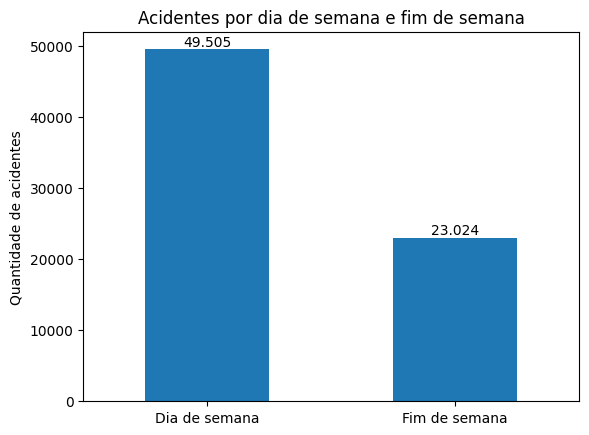

In [42]:
ax = resultado.plot(
    x="fim_de_semana",
    y="qtd_acidentes",
    kind="bar",
    legend=False
)

ax.set_title("Acidentes por dia de semana e fim de semana")
ax.set_xlabel("")
ax.set_ylabel("Quantidade de acidentes")

for barra in ax.patches:
    ax.annotate(
        f"{int(barra.get_height()):,}".replace(",", "."),
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=0)
plt.show()